<div style="width: 70%; margin: 0 auto; text-align: center;">
    <h1>HEALTH INSURANCE PREMIUM PREDICTION</h1>
    <img src="./Resources/Images/health_insurance_img.jpeg" width=500px height=300px alt="Health insurance image"></img>
    <p> <b>SHIELD INSURANCE</b> - an insurance provider intends to find out the possible premiums future prospective customers would want to pay toward purchase of health insurance. To help them achieve this task we use ML models to accurately predict the same.</p>
</div>

In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import optuna
from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
premium_df = pd.read_excel('./Resources/Dataset/premiums.xlsx')

In [4]:
# get shape of dataframe
premium_df.shape

(50000, 13)

In [5]:
# check first few samples from the data
premium_df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


Observations, 
* `Annual_Premium_Amount` is the target variable that we'd want to predict for unknown set of customers. 
* `Insurance Plan` indicates the different tiers of plans present with increasing perks at the expense of higher premiums in the order of Gold > Silver > Bronze. 
* All currency unit is represented in *INR*.

In [6]:
premium_df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


Observations, 
* `Age` shows a max value of 356 yrs which is certainly absurd and needs to be handled. 
* `Number of dependents` shows a min value of -3 which is absurd and needs handling. Usually `No of dependents` cannot be lower than 0. Hence for absurd values we replace them with suitable ones depending upon other factors such as `Marital Status` etc or we can talk to business and come up with suitable modifictaions.
* There exists several columns with `Null` values present that must be either replaced with suitable values or dropped depending upon the percentage of it w.r.t the data size.

In [7]:
premium_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


#### SPLIT DATA INTO TRAIN AND TEST SET
Below we split data into train and test set.

In [8]:
# remove target label
y = premium_df.pop('Annual_Premium_Amount')

In [10]:
# sanity check for removal of target label
premium_df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan'],
      dtype='object')

In [11]:
# split data into reproducible train and test sets
premium_train_df, premium_test_df, y_train, y_test = train_test_split(premium_df,y,test_size=0.2,random_state=42)

In [12]:
# check train and test sizes
print(f'Train-size: {premium_train_df.shape[0]}, Test-size: {premium_test_df.shape[0]}')

Train-size: 40000, Test-size: 10000


### DATA COLLECTION AND CLEANING
*SHIELD INSURANCE* contacted a third-party vendor to gather data related to customers with health insurance. The data is shared in the form of an excel sheet. 

Below we check if any **Data preprocessing** is needed seperately on train and test sets to achieve the following, 
* Impute missing values 
* Handle outliers 
* Removal of duplicates 
* Handle absurd data across features etc.

In [13]:
# check for NA values in train and test sets
premium_train_df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status          10
Employment_Status        2
Income_Level            10
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
dtype: int64

In [14]:
# check for NA in test sets
premium_test_df.isna().sum()

Age                     0
Gender                  0
Region                  0
Marital_status          0
Number Of Dependants    0
BMI_Category            0
Smoking_Status          1
Employment_Status       0
Income_Level            3
Income_Lakhs            0
Medical History         0
Insurance_Plan          0
dtype: int64

##### HANDLE NA VALUES
Below we remove **NULL** values from both the train and test sets since they form only a small fraction of the entire dataset size.

In [15]:
# drop NA samples from train set
premium_train_df.dropna(inplace=True)
y_train = y_train.loc[premium_train_df.index]

# drop NA samples from test set
premium_test_df.dropna(inplace=True)
y_test = y_test.loc[premium_test_df.index]

In [16]:
# sanity check for presence of NA samples in train sets
premium_train_df.isna().sum()

Age                     0
Gender                  0
Region                  0
Marital_status          0
Number Of Dependants    0
BMI_Category            0
Smoking_Status          0
Employment_Status       0
Income_Level            0
Income_Lakhs            0
Medical History         0
Insurance_Plan          0
dtype: int64

In [17]:
# sanity check for presence of NA samples in test sets
premium_test_df.isna().sum()

Age                     0
Gender                  0
Region                  0
Marital_status          0
Number Of Dependants    0
BMI_Category            0
Smoking_Status          0
Employment_Status       0
Income_Level            0
Income_Lakhs            0
Medical History         0
Insurance_Plan          0
dtype: int64

##### CHECK FOR DUPLICATES
Below we check for duplicates in train and test set. In case it is present we omit it.

In [18]:
# check for duplicates in train set
premium_train_df.duplicated().any()

np.True_

In [19]:
# fetch the duplicated samples
train_duplicated_df = premium_train_df[premium_train_df.duplicated()]

In [20]:
train_duplicated_df.shape

(804, 12)

In [21]:
# check first few duplicated rows
train_duplicated_df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
26653,20,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,10L - 25L,12,No Disease,Bronze
48975,22,Female,Southwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,4,No Disease,Bronze
15165,40,Female,Southwest,Married,3,Normal,No Smoking,Self-Employed,10L - 25L,18,High blood pressure,Silver
15599,20,Female,Northeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,5,No Disease,Bronze
40431,19,Male,Southeast,Unmarried,1,Normal,Regular,Freelancer,<10L,2,No Disease,Bronze


In [22]:
# check for duplicates in test set
premium_test_df.duplicated().sum().item()

65

Observations, 
* We find several duplicate entries in the data in terms of features but with differing target labels. There exists 804/40000 duplicated samples in train set. Since it form `~2%` of the whole data we keep the first occurance and drop the rest. 

* There exists 65/10000 duplicates amongst test set.

In [23]:
# drop duplicates keeping the first in both train and test sets

# train set duplicate removal
premium_train_df.drop_duplicates(keep='first',inplace=True)
y_train = y_train.loc[premium_train_df.index]

premium_test_df.drop_duplicates(keep='first',inplace=True)
y_test = y_test.loc[premium_test_df.index]

In [24]:
# sanity check for duplicates dropped
premium_train_df.duplicated().any(), premium_test_df.duplicated().any()

(np.False_, np.False_)

##### REPLACE ABSURD NUMBER OF DEPENDENTS
We found that min value of number of dependents being negative. 

It could be that the negative sign for `Number of dependents` is mistakenly included in which case we can simply take the absolute values.

In [25]:
# convert all values under Number Of Dependents to be non-negative in both train & test sets
premium_train_df['Number Of Dependants'] = abs(premium_train_df['Number Of Dependants'])
premium_test_df['Number Of Dependants'] = abs(premium_test_df['Number Of Dependants'])

In [26]:
# sanity check for all non-negative dependents
print(f'Range of num of dependents in train-set is: {premium_train_df["Number Of Dependants"].min()}-{premium_train_df["Number Of Dependants"].max()}')
print(f'Range of num of dependents in test-set is: {premium_test_df["Number Of Dependants"].min()}-{premium_test_df["Number Of Dependants"].max()}')

Range of num of dependents in train-set is: 0-5
Range of num of dependents in test-set is: 0-5


##### CHECK FOR AND HANDLE OUTLIERS
Above we found that max `Age` to be 365 yrs which is absurd hence we treat it below.

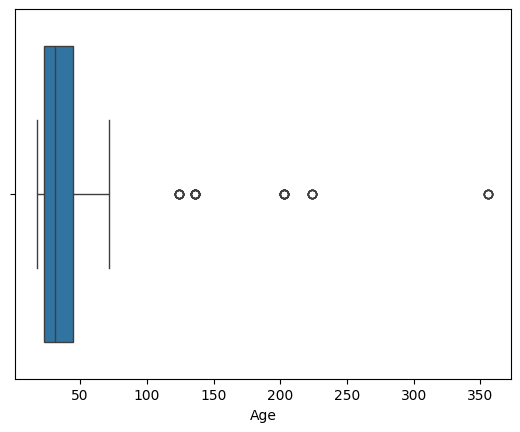

In [27]:
# plot boxplot for Age to check for outliers in train set
sns.boxplot(data=premium_train_df,x='Age')
plt.show()

Observations, 
* From above we find that there exists several values under `Age` attribute that are outliers. 
* One way to treat them is to replace the outliers with median `Age` since median is robust to outliers or one can use a suitable threshold such as `120 years` so that only samples <=threshold is retained filtering out the rest.

In [28]:
# prune dataset and make a shallow copy to retain only samples upto 120 yrs of age for both train & test sets.
age_threshold = 120

# prune for train
X_train = premium_train_df[premium_train_df['Age']<=age_threshold].copy()
y_train = y_train.loc[X_train.index]

# prune for test
X_test = premium_test_df[premium_test_df['Age']<=age_threshold].copy()
y_test = y_test.loc[X_test.index]

In [29]:
# sanity check for age range in train and test sets
print(f'Age range in train-set is: {X_train["Age"].min()}-{X_train["Age"].max()} yrs')
print(f'Age range in test-set is: {X_test["Age"].min()}-{X_test["Age"].max()} yrs')

Age range in train-set is: 18-72 yrs
Age range in test-set is: 18-72 yrs


##### INCOME DISTRIBUTION
Below we look at `Income_Lakhs` attribute distribution in train set.

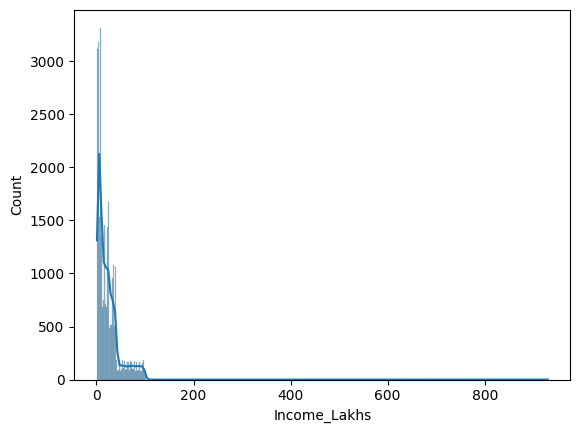

In [30]:
sns.histplot(data=X_train,x='Income_Lakhs',kde=True)
plt.show()

In [31]:
print(f'Max income is: {X_train["Income_Lakhs"].max()} Lakhs')

Max income is: 930 Lakhs


Observations, 
* Highest income being `~9.3 Cr` is possible in India and hence we do not filter out any sample basis outliers in `Income_Lakhs` attribute.

In [32]:
# sanity check for descriptive statistics in train set
X_train.describe()

,Age,Number Of Dependants,Income_Lakhs
count,39135.000000,39135.000000,39135.000000
mean,34.636412,1.744525,23.283327
std,13.709018,1.491255,24.575529
min,18.000000,0.000000,1.000000
25%,23.000000,0.000000,7.000000
50%,31.000000,2.000000,17.000000
75%,45.000000,3.000000,32.000000
max,72.000000,5.000000,930.000000


In [33]:
# sanity check for right descriptive statistics for test set
X_test.describe()

,Age,Number Of Dependants,Income_Lakhs
count,9914.000000,9914.000000,9914.00000
mean,34.493948,1.725439,23.00121
std,13.617004,1.491313,23.41432
min,18.000000,0.000000,1.00000
25%,23.000000,0.000000,7.00000
50%,31.000000,2.000000,17.00000
75%,45.000000,3.000000,32.00000
max,72.000000,5.000000,580.00000


##### CHECK UNIQUE VALUES UNDER CATEGORICAL ATTRIBUTES
Below we check unique values under each categorical attribute in train set.

In [34]:
cat_cols = list(X_train.select_dtypes(include='object').columns)

In [35]:
# check all unique values in categorical cols
for col in cat_cols:
    print({col:X_train[col].unique()})

{'Gender': array(['Female', 'Male'], dtype=object)}
{'Region': array(['Southwest', 'Northwest', 'Southeast', 'Northeast'], dtype=object)}
{'Marital_status': array(['Unmarried', 'Married'], dtype=object)}
{'BMI_Category': array(['Normal', 'Obesity', 'Underweight', 'Overweight'], dtype=object)}
{'Smoking_Status': array(['No Smoking', 'Regular', 'Occasional', 'Smoking=0', 'Not Smoking',
       'Does Not Smoke'], dtype=object)}
{'Employment_Status': array(['Salaried', 'Self-Employed', 'Freelancer'], dtype=object)}
{'Income_Level': array(['25L - 40L', '<10L', '10L - 25L', '> 40L'], dtype=object)}
{'Medical History': array(['High blood pressure', 'No Disease', 'Diabetes & Heart disease',
       'Thyroid', 'Diabetes & Thyroid',
       'High blood pressure & Heart disease', 'Heart disease', 'Diabetes',
       'Diabetes & High blood pressure'], dtype=object)}
{'Insurance_Plan': array(['Silver', 'Bronze', 'Gold'], dtype=object)}


Observations, 
* Above indicates that for `Smoking_Status` attribute a lot of the values are synonymous such as `Smoking=0`,`Not Smoking`,`Does not smoke` & `No Smoking`. We can replace all of these by a single value say `No Smoking`.

In [36]:
smoking_dict = {
    'Smoking=0': 'No Smoking',
    'Not Smoking' : 'No Smoking',
    'Does Not Smoke' : 'No Smoking',
    'Regular':'Regular',
    'Occasional' : 'Occasional',
    'No Smoking' : 'No Smoking'
}

# replace all with 'No Smoking' in both train and test sets
X_train['Smoking_Status'] = X_train['Smoking_Status'].map(smoking_dict)
X_test['Smoking_Status'] = X_test['Smoking_Status'].map(smoking_dict)

In [37]:
# sanity check for unique values under smoking status for both trainn and test
X_train['Smoking_Status'].unique()
X_test['Smoking_Status'].unique()

array(['Occasional', 'Regular', 'No Smoking'], dtype=object)

### EDA
Below we visualize some distributions to see how things look like in training set.

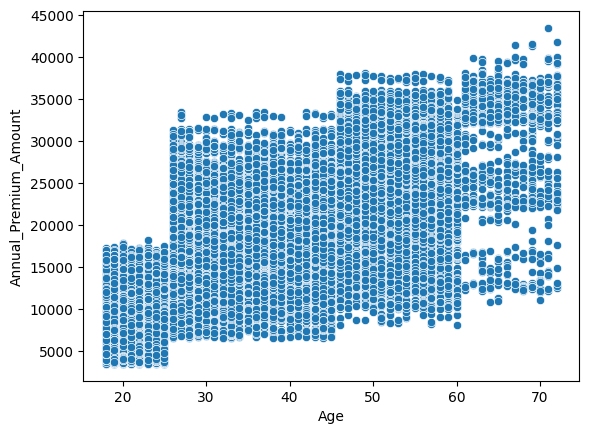

In [38]:
# scatterplot between age & annual premium amount paid for insurance
sns.scatterplot(x=X_train['Age'],y=y_train)
plt.show()

Observations, 
* As expected with `Age` people tend to purchase better insurance policies out there in the market that calls for higher `Annual_Premium_Amount`.

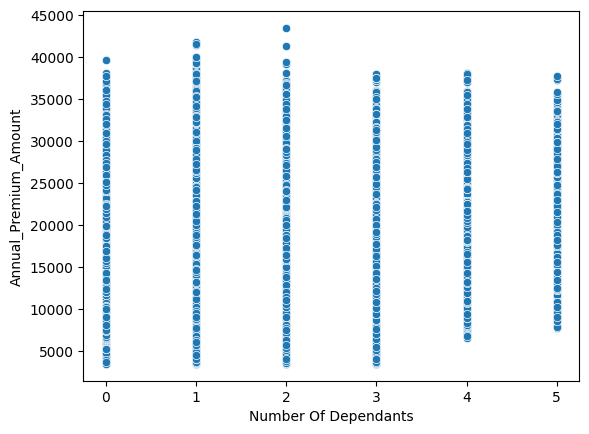

In [39]:
# scatterplot between annual premium amount and number of dependents
sns.scatterplot(x=X_train['Number Of Dependants'],y=y_train)
plt.show()

Observations, 
* There seems to be no apparent dependence between `No of dependents` & `Annual Premium Amount`.

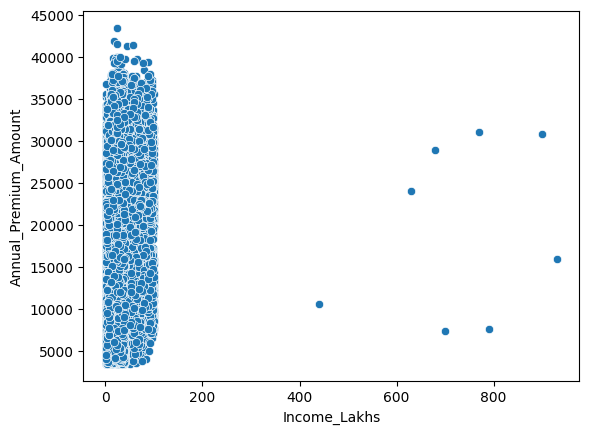

In [40]:
# scatterplot between income level and annual premium amt paid for insurance
sns.scatterplot(x=X_train['Income_Lakhs'],y=y_train)
plt.show()

Observations, 
* Above figure confirms no apparent relation between `Income` & `Annual premium amount` towards insurance.

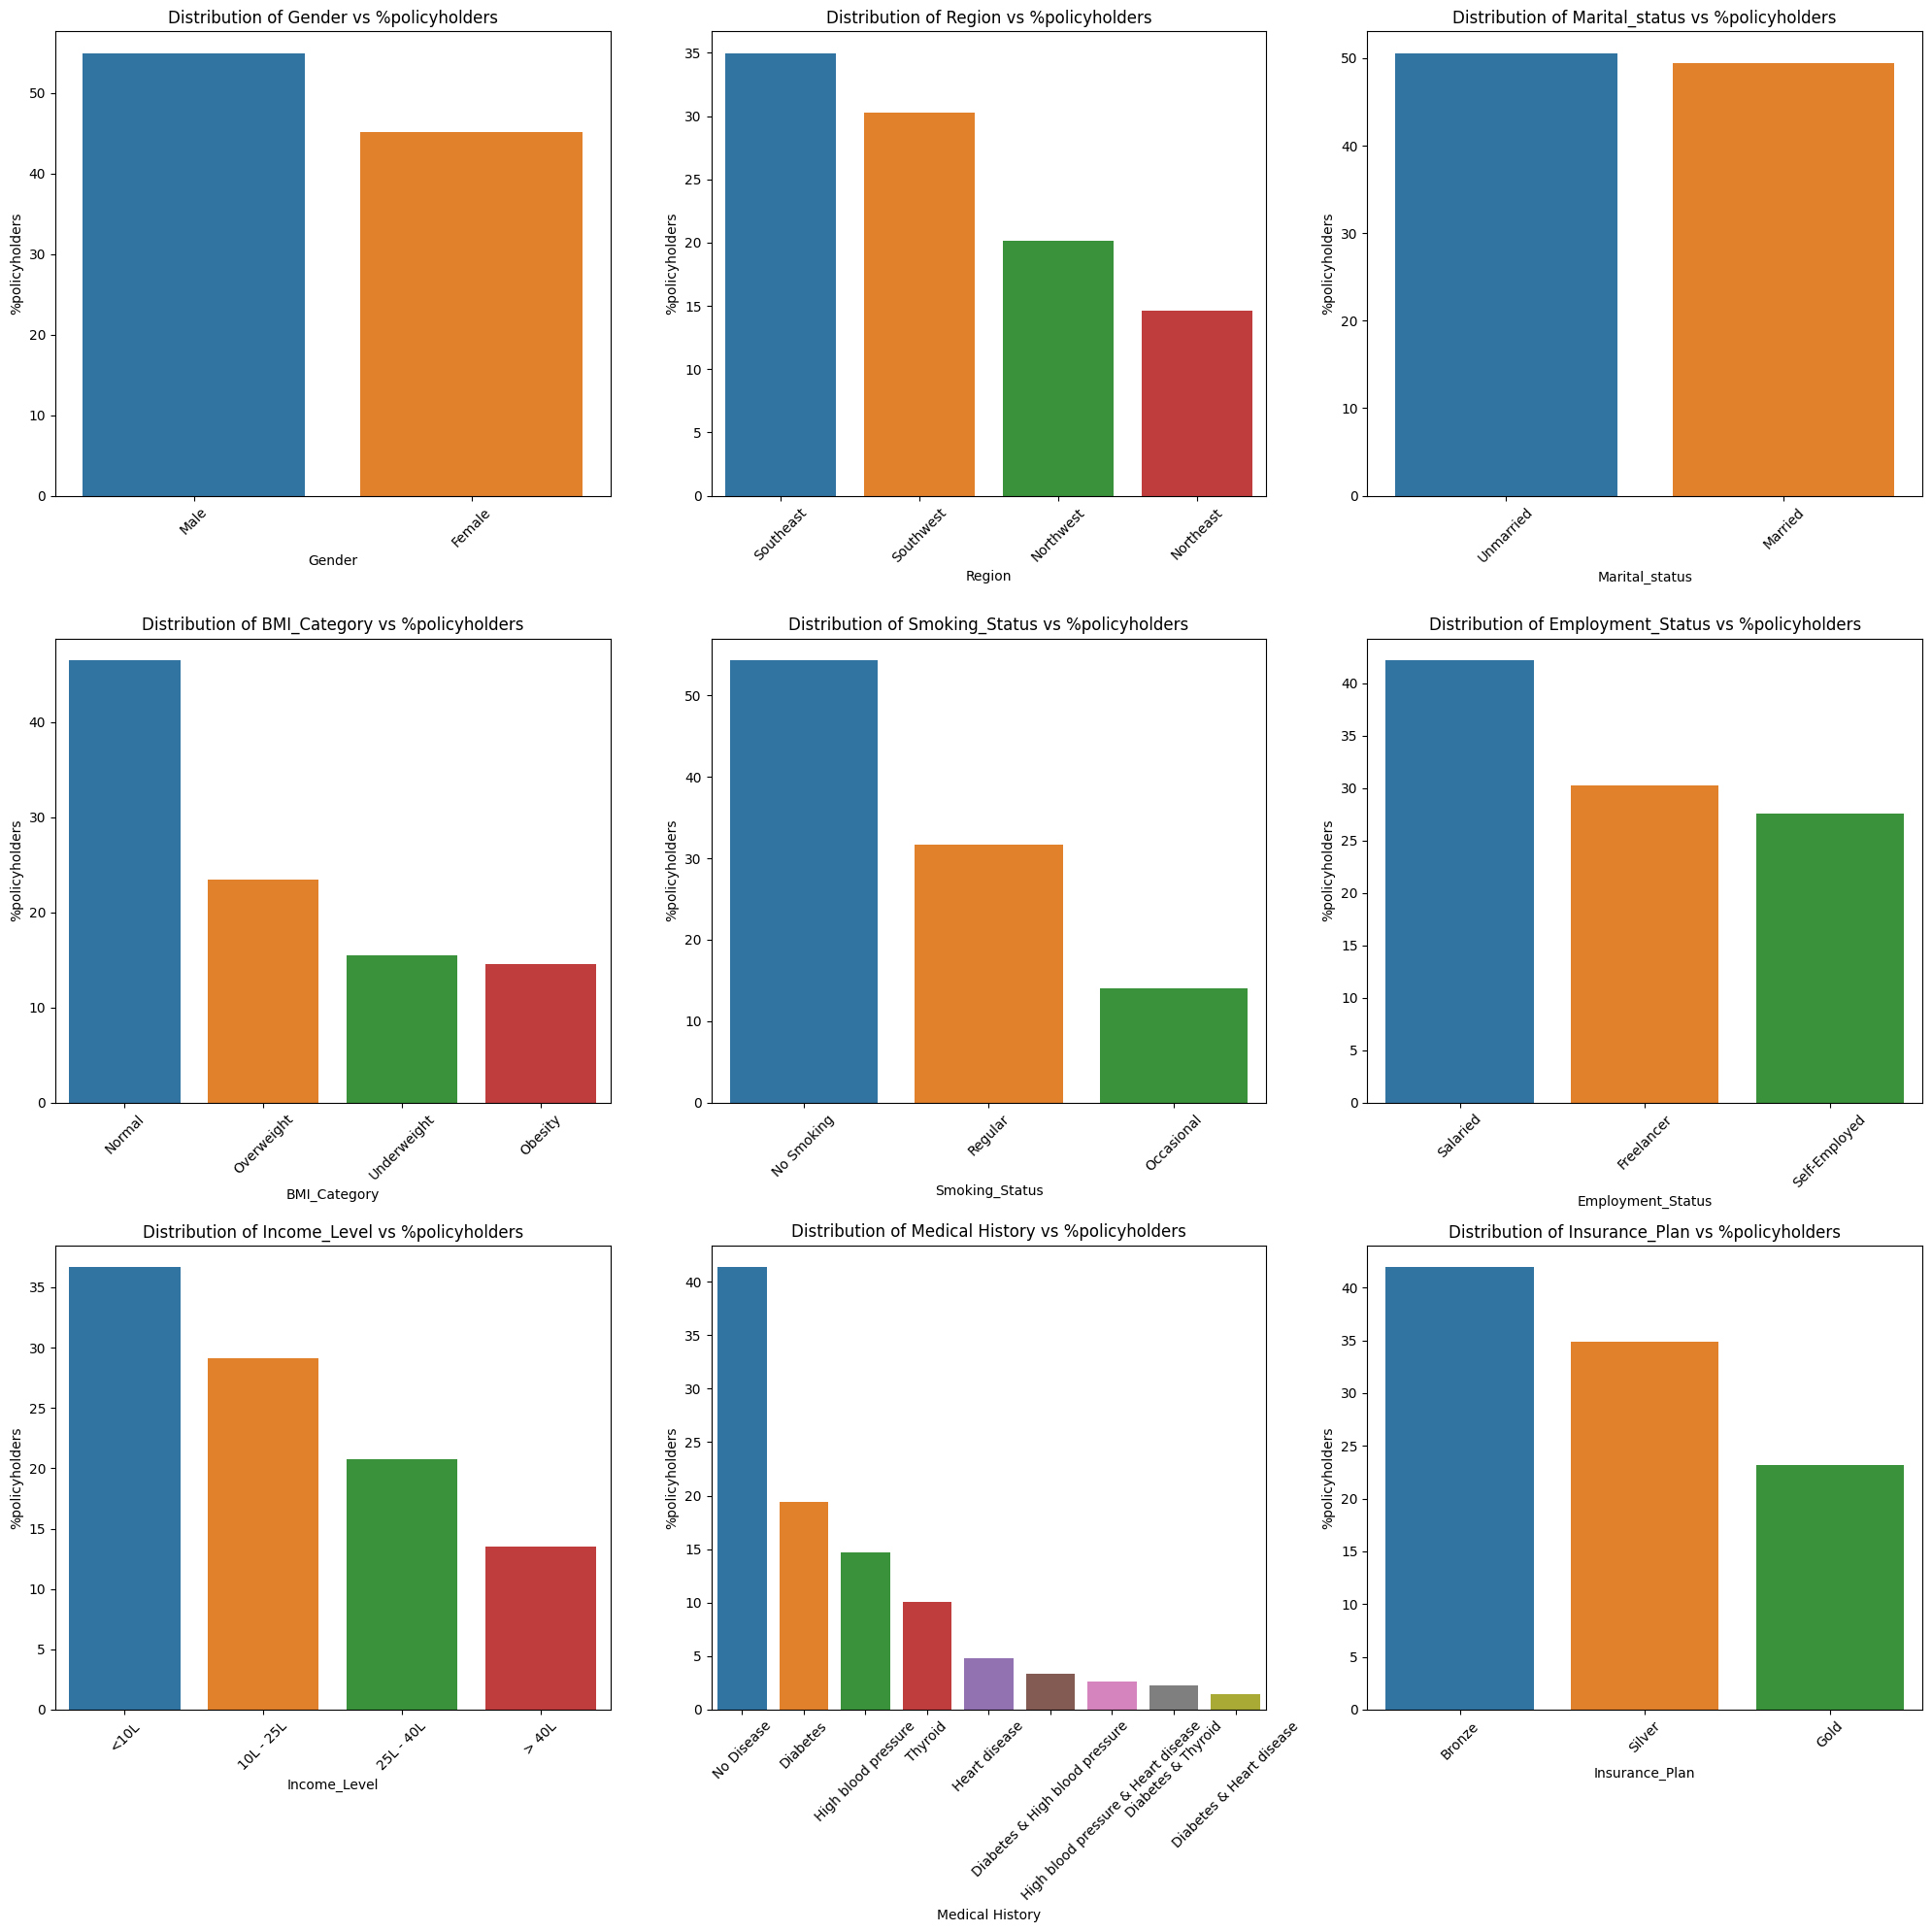

In [41]:
fig, axes = plt.subplots(nrows=3,ncols=3)

# flatten axes from 3x3 -> 9
axes = axes.flatten()

# set figsize
fig.set_figwidth(20)
fig.set_figheight(20)

for ax,col in zip(axes,cat_cols):   
    counts = X_train[col].value_counts(normalize=True)*100

    # plot category columnwise policyholders
    sns.barplot(x=counts.index,y=counts.values,ax=ax,hue=counts.index)
    ax.set_title(f'Distribution of {col} vs %policyholders')
    ax.set_xlabel(col)
    ax.set_ylabel('%policyholders')
    ax.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

### FEATURE ENGINEERING

In [42]:
# look at first few rows of dataframe
X_train.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
39087,29,Female,Southwest,Unmarried,0,Normal,No Smoking,Salaried,25L - 40L,28,High blood pressure,Silver
30893,55,Male,Southwest,Married,3,Normal,No Smoking,Salaried,<10L,5,High blood pressure,Silver
45278,18,Male,Northwest,Unmarried,0,Normal,Regular,Salaried,25L - 40L,34,No Disease,Bronze
16398,31,Female,Southeast,Married,2,Obesity,No Smoking,Salaried,<10L,5,Diabetes & Heart disease,Silver
13653,67,Male,Northwest,Married,1,Underweight,No Smoking,Self-Employed,25L - 40L,29,Thyroid,Gold


In [43]:
# get cardinality of all categorical features
X_train[cat_cols].nunique()

Gender               2
Region               4
Marital_status       2
BMI_Category         4
Smoking_Status       3
Employment_Status    3
Income_Level         4
Medical History      9
Insurance_Plan       3
dtype: int64

Observations, 

For train-set we perform the following - 
* We enode `Insurance Plan`, `Smoking status`, `Income level` & `BMI` using **ORDINAL ENCODER** since all these assume an inherent order. 
* Use **OHE** for `Gender`, `Region`, `Marital Status` & `Employment status`. 
* Use **TARGET ENCODING** for `Medical History` using OOF CV to avoid leakage.

In [44]:
# do sanity check for absence of target attribute
X_train.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan'],
      dtype='object')

In [45]:
X_train.shape

(39135, 12)

In [46]:
X_test.shape

(9914, 12)

In [47]:
y_train.shape, y_test.shape

((39135,), (9914,))

In [48]:
# reset indices for both train and test sets such that position = labels dropping the old indices

# train set
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# test set
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [49]:
# sanity check for position based indexing
X_train.index.values[:5]

array([0, 1, 2, 3, 4])

#### TARGET ENCODING USING OOF CV
Below we perform `Target Encoding` of *Medical History* using Leakage free OOF CV.

In [50]:
def oof_cv_target_encoding(X_train: pd.DataFrame,y_train: pd.Series, X_test: pd.DataFrame, target_column):
    '''
    Function that performs Target Encoding using leakage-free OOF CV for both train and test sets.
    For unseen categories foldwise training mean is used.
    '''
    # perform 5-fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # store target encoded output
    X_train_te = X_train.copy()
    X_test_te = X_test.copy()

    for train_idx, val_idx in kf.split(X_train):

        # split dataset into train and validation folds using positions
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # join train-fold features and labels
        X_trfold = X_tr.join(y_tr)

        # find medical history wise mean Annual premium paid
        medhist_mean_annualpremium = X_trfold.groupby([target_column])['Annual_Premium_Amount'].agg('mean')

        # target encode Medical History attribute in target encoded training set at indexes set by validation fold
        X_train_te.loc[val_idx,target_column] = X_val[target_column].map(medhist_mean_annualpremium).fillna(y_tr.mean())

    # target encode test set using Global training set
    X_train = X_train.join(y_train)
    X_train_medhist_mean_annualpremium = X_train.groupby([target_column])['Annual_Premium_Amount'].agg('mean')
    X_test_te[target_column] = X_test[target_column].map(X_train_medhist_mean_annualpremium).fillna(y_train.mean())
    
    # change column datatype from object -> numeric
    X_train_te[target_column] = pd.to_numeric(X_train_te[target_column],errors='coerce')
    X_test_te[target_column] = pd.to_numeric(X_test_te[target_column], errors='coerce')

    return X_train_te,X_test_te

In [51]:
X_train_te, X_test_te = oof_cv_target_encoding(X_train,y_train,X_test, 'Medical History')

In [52]:
# sanity check to ensure Medical History is target encoded
X_train_te.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
0,29,Female,Southwest,Unmarried,0,Normal,No Smoking,Salaried,25L - 40L,28,19839.473144,Silver
1,55,Male,Southwest,Married,3,Normal,No Smoking,Salaried,<10L,5,19891.561510,Silver
2,18,Male,Northwest,Unmarried,0,Normal,Regular,Salaried,25L - 40L,34,10123.008128,Bronze
3,31,Female,Southeast,Married,2,Obesity,No Smoking,Salaried,<10L,5,20457.249467,Silver
4,67,Male,Northwest,Married,1,Underweight,No Smoking,Self-Employed,25L - 40L,29,19658.574381,Gold


In [53]:
# sanity check on test set
X_test_te.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
0,28,Male,Southeast,Married,3,Overweight,Occasional,Self-Employed,25L - 40L,30,19786.205539,Silver
1,24,Female,Southeast,Unmarried,0,Underweight,Occasional,Freelancer,10L - 25L,16,10138.699345,Silver
2,31,Male,Southeast,Married,4,Normal,Regular,Salaried,<10L,2,19752.426549,Bronze
3,58,Male,Northwest,Married,3,Overweight,Regular,Self-Employed,<10L,8,19745.239379,Bronze
4,53,Male,Southeast,Married,2,Overweight,Regular,Self-Employed,25L - 40L,30,19786.205539,Gold


In [54]:
X_train_te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39135 entries, 0 to 39134
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   39135 non-null  int64  
 1   Gender                39135 non-null  object 
 2   Region                39135 non-null  object 
 3   Marital_status        39135 non-null  object 
 4   Number Of Dependants  39135 non-null  int64  
 5   BMI_Category          39135 non-null  object 
 6   Smoking_Status        39135 non-null  object 
 7   Employment_Status     39135 non-null  object 
 8   Income_Level          39135 non-null  object 
 9   Income_Lakhs          39135 non-null  int64  
 10  Medical History       39135 non-null  float64
 11  Insurance_Plan        39135 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 3.6+ MB


#### SETUP DATA TRANSFORMATION PIPELINE
Below we set data transformation pipeline to preprocess attributes of the dataset.

In [55]:
num_pipeline = make_pipeline(StandardScaler())

cat_pipeline1 = make_pipeline(OneHotEncoder())

cat_pipeline2 = make_pipeline(OrdinalEncoder())

preprocessing = make_column_transformer(
    (num_pipeline,make_column_selector(dtype_include=np.number)),
    (cat_pipeline1,['Gender', 'Region', 'Marital_status','Employment_Status']),
    remainder=cat_pipeline2
)

#### OOF-CV PERFORMANCE MEASURE
For each model we measure performance basis `5-FOLD OOF CV` technique that accurately captures performance.

In [56]:
def oof_cv_performance(model_pipeline, X_train, y_train, X_test):
    '''
    Function that determines model performance using 5-Fold OOF-CV method.
    In addition we also make predictions on test set using foldwise trained models before taking the mean prediction to be the final result.
    '''

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # store RMSE results foldwise and predictions
    rmse_foldwise = []
    model_preds = np.zeros(y_train.shape)

    # store test predictions using foldwise trained model
    foldwise_test_preds = []

    for tr_idx, val_idx in kf.split(X_train):

        # split data into train and validation folds
        X_trfold, y_trfold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_valfold, y_valfold = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # setup fresh untrained model in every fold
        model = clone(model_pipeline)

        # train model on train fold and predict on validation folds selecting an untrained model everytime
        model.fit(X_trfold,y_trfold)
        y_pred_valfold = model.predict(X_valfold)

        # store predictions
        model_preds[val_idx] = y_pred_valfold

        # store result foldwise
        fold_rmse = root_mean_squared_error(y_valfold,y_pred_valfold)
        rmse_foldwise.append(fold_rmse)

        # store test predictions using trained model
        test_pred = model.predict(X_test)
        foldwise_test_preds.append(test_pred)
    
    mean_rmse_overall = np.asarray(rmse_foldwise).mean()
    std_rmse = np.asarray(rmse_foldwise).std()

    rmse_on_trainset = root_mean_squared_error(y_train,model_preds)
    r2_score_on_trainset = r2_score(y_train,model_preds)

    # get final test predictions as mean of all fold predictions
    test_pred_final = np.mean(foldwise_test_preds,axis=0)

    return mean_rmse_overall, std_rmse, rmse_on_trainset, r2_score_on_trainset, test_pred_final

### ML MODELS PERFORMANCE CHECK
Below we test out some ML models, baselines first followed by tuning hyperparameters to see how they perform & finally choose the most optimal model, 
* `LINEAR REGRESSION` 
* `RANDOM FOREST REGRESSOR` 
* `ADABOOST`
* `GRADIENT BOOSTING REGRESSOR` 
* `XGBOOST REGRESSOR`

#### BASELINE LINEAR REGRESSION

In [57]:
linreg_pipeline = make_pipeline(preprocessing,LinearRegression())

# check model performance using OOF-CV
linreg_mean_rmse, linreg_rmse_std, linreg_rmse_on_trainset, linreg_rsquared_on_trainset, linreg_test_pred = oof_cv_performance(linreg_pipeline,X_train_te,y_train,X_test_te)

# display results
print(f'Linear regression baseline OOF-CV mean RMSE: {linreg_mean_rmse}, Std deviation: {linreg_rmse_std}, Train RMSE: {linreg_rmse_on_trainset}, Train R-squared: {linreg_rsquared_on_trainset}')

Linear regression baseline OOF-CV mean RMSE: 4327.929075738359, Std deviation: 55.23308735551914, Train RMSE: 4328.281504079917, Train R-squared: 0.7348121803773824


Observations, 
* `R-square` captures variance in `Annual premium amount` hence here model captures *73.5%* of variance or trend in the label.
* `RMSE` of INR *~4328* gives a relative error of *~27%* towards estimation of `Annual premium amount` accurately.

#### BASELINE RANDOM FOREST CLASSIFIER
Below we use a baseline *RandomForestRegressor* with the following properties, 
* `Max depth`=5 
* `Number of estimators`=10

In [58]:
randforest_pipeline = make_pipeline(preprocessing,RandomForestRegressor(random_state=42,max_depth=5,n_estimators=10))

# check model performance using OOF-CV
randforest_mean_rmse, randforest_rmse_std, randforest_rmse_on_trainset, randforest_rsquared_on_trainset, randforest_test_pred = oof_cv_performance(randforest_pipeline,X_train_te,y_train,X_test_te)

# display results
print(f'RandomForestRegressor baseline OOF-CV mean RMSE: {randforest_mean_rmse}, Std deviation: {randforest_rmse_std}, Train RMSE: {randforest_rmse_on_trainset}, Train R-squared: {randforest_rsquared_on_trainset}')

RandomForestRegressor baseline OOF-CV mean RMSE: 1988.9945328259878, Std deviation: 14.61566019558192, Train RMSE: 1989.048231977953, Train R-squared: 0.9439967535046505


Observations, 
* As observed *Random Forest Regressor* yields much better performance with *~94.3%* variance in `Annual Premium amount` captured. 
* `RMSE` of INR ~*1988* indicates a relative error of ~*12.5%* towards accurate estimation of `Annual Premium amount` which is much better than baseline `Linear Regression` used above.

##### GRADIENT BOOSTING REGRESSOR
Below we use a *GRADIENT BOOSTING REGRESSOR* that uses boosted trees in a sequential fashion such that each tree attemps to correct the errors made by its predecessors. Here we use a baseline model with the following properties, 
* `Number of estimators`=20 
* `Max depth`=5 
* `Learning rate`=0.1 (default)

In [59]:
gradboost_pipeline = make_pipeline(preprocessing,GradientBoostingRegressor(random_state=42,max_depth=5,learning_rate=0.1,n_estimators=20))

# check OOF-CV performance
gradboost_mean_rmse, gradboost_rmse_std, gradboost_rmse_trainset, gradboost_rsquared_trainset, gradboost_test_pred = oof_cv_performance(gradboost_pipeline,X_train_te,y_train,X_test_te)

# display results
print(f'GradBoostRegressor baseline OOF-CV mean RMSE: {gradboost_mean_rmse}, Std deviation: {gradboost_rmse_std}, Train RMSE: {gradboost_rmse_trainset}, Train R-squared: {gradboost_rsquared_trainset}')

GradBoostRegressor baseline OOF-CV mean RMSE: 1877.0089771814514, Std deviation: 14.72678603721763, Train RMSE: 1877.0667485858737, Train R-squared: 0.9501251034570491


observations, 
* `Vanilla Gradient Boosting Regressor` yields better performance as compared to `Random Forest Regressor` above with ~*95%* variance captured in `Annual Premium amount`. 
* `RMSE` of INR ~*1877* implies a much lower relative-error rate of ~*11.77%* which suggests higher precision towards accurate estimation of `Annual premium amount`.

##### XGBOOST REGRESSOR
Below we use a baseline *XGBOOST REGRESSOR* which uses a combination of *gradients & hessians* to arrive at predictions with the following properties, 
* `Number of estimators`=100 
* `Learning Rate`=0.05 
* `Max depth`=5 

In [60]:
xgboostreg_pipeline = make_pipeline(preprocessing, XGBRegressor(n_estimators=100,learning_rate=0.05,max_depth=5,random_state=42))

# check OOF-CV performance
xgbreg_mean_rmse, xgbreg_rmse_std, xgbreg_rmse_trainset, xgbreg_rsquared_trainset, xgbreg_test_pred = oof_cv_performance(xgboostreg_pipeline,X_train_te,y_train,X_test_te)

# display results
print(f'XGBRegressor baseline OOF-CV mean RMSE: {xgbreg_mean_rmse}, Std deviation: {xgbreg_rmse_std}, Train RMSE: {xgbreg_rmse_trainset}, Train R-squared: {xgbreg_rsquared_trainset}')

XGBRegressor baseline OOF-CV mean RMSE: 1209.4494384765626, Std deviation: 68.03954246463839, Train RMSE: 1211.3617531986413, Train R-squared: 0.9792283837868526


observations, 
* `XGBoost Regressor` outperforms `Gradient Boosting Regressor` with ~*98%* capture of variance in `Annual Premium amount`. 
* `RMSE` of ~*1211* INR suggests an even smaller relative-error rate of ~*7.5%* indicative of even accurate estimate of `Annual Premium amount`. 

### ERROR ANALYSIS
Below we perform *ERROR ANALYSIS* on all of the above models to find out where things went wrong. 

In [61]:
# check on descriptive statistics of target
y_test.describe()

count     9914.000000
mean     15786.138894
std       8412.426984
min       3505.000000
25%       8673.000000
50%      13964.000000
75%      22289.750000
max      43119.000000
Name: Annual_Premium_Amount, dtype: float64

##### LINEAR REGRESSION

In [62]:
# find residual pct for each oof-cv prediction
linreg_residual_pct = ((linreg_test_pred - y_test)/y_test)*100

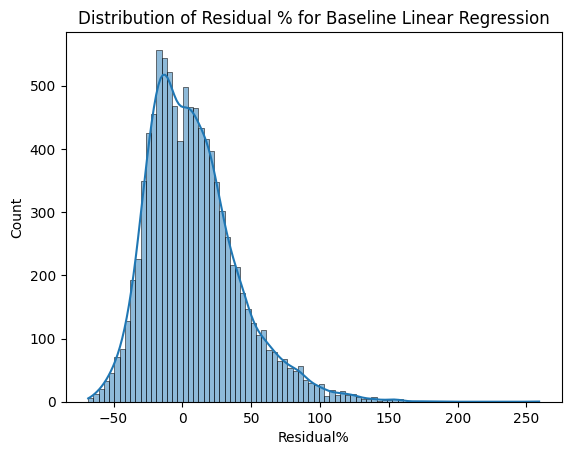

In [63]:
# plot distribution of residual against predictions
sns.histplot(linreg_residual_pct,kde=True)
plt.title("Distribution of Residual % for Baseline Linear Regression")
plt.xlabel('Residual%')
plt.show()

Observations, 
* Above plot indicates that `Baseline Linear Regression` model shows up residuals as high as *250%* indicating that it doesn't perform well. An `Annual premium amount` set as INR 15000 might actually be estimated to be ~INR *52500* considering the above residual. 

An ideal model would be one with max residual pct within ~*10%*.

In [64]:
# find out samples for which predictions turn out to be extremely erroneous i.e. >10%
indices_of_extreme_errors = linreg_residual_pct[abs(linreg_residual_pct)>10].index
linreg_extreme_errors_df = X_test.loc[indices_of_extreme_errors]

# display first few samples
linreg_extreme_errors_df.head()


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
1,24,Female,Southeast,Unmarried,0,Underweight,Occasional,Freelancer,10L - 25L,16,No Disease,Silver
2,31,Male,Southeast,Married,4,Normal,Regular,Salaried,<10L,2,Thyroid,Bronze
3,58,Male,Northwest,Married,3,Overweight,Regular,Self-Employed,<10L,8,Diabetes,Bronze
4,53,Male,Southeast,Married,2,Overweight,Regular,Self-Employed,25L - 40L,30,High blood pressure,Gold
6,28,Male,Southwest,Married,2,Obesity,Regular,Salaried,> 40L,99,Thyroid,Gold


In [65]:
# compute pct of extreme errors
print(f'Baseline Linear Regression predictions that have residuals >10% is: {(linreg_extreme_errors_df.shape[0]/X_test_te.shape[0])*100}% of the whole test dataset')

Baseline Linear Regression predictions that have residuals >10% is: 74.96469638894493% of the whole test dataset


In [66]:
def plot_test_distributions_and_extreme_errors_distributions(extreme_errors):
    '''
    Function that plots distribution of original test data and a subset of test data where model makes error > 10%.
    '''
    # display plots of distribution of each of the features in extereme error group and the whole of test data
    fig, axes = plt.subplots(nrows=4,ncols=3)
    fig.set_figwidth(15)
    fig.set_figheight(15)

    # flatten axes
    axes = axes.flatten()

    # columns to plot
    cols = extreme_errors.columns

    for ax, col in zip(axes,cols):

        # plot test data distribution
        sns.histplot(x=X_test[col],kde=True, color='blue', label='Overall',ax=ax)

        # plot distribution in extreme group
        sns.histplot(x=extreme_errors[col],kde=True, color='red', label='Extreme errors',ax=ax) 
        ax.tick_params(axis='x',rotation=45)
        ax.legend()

    plt.show()

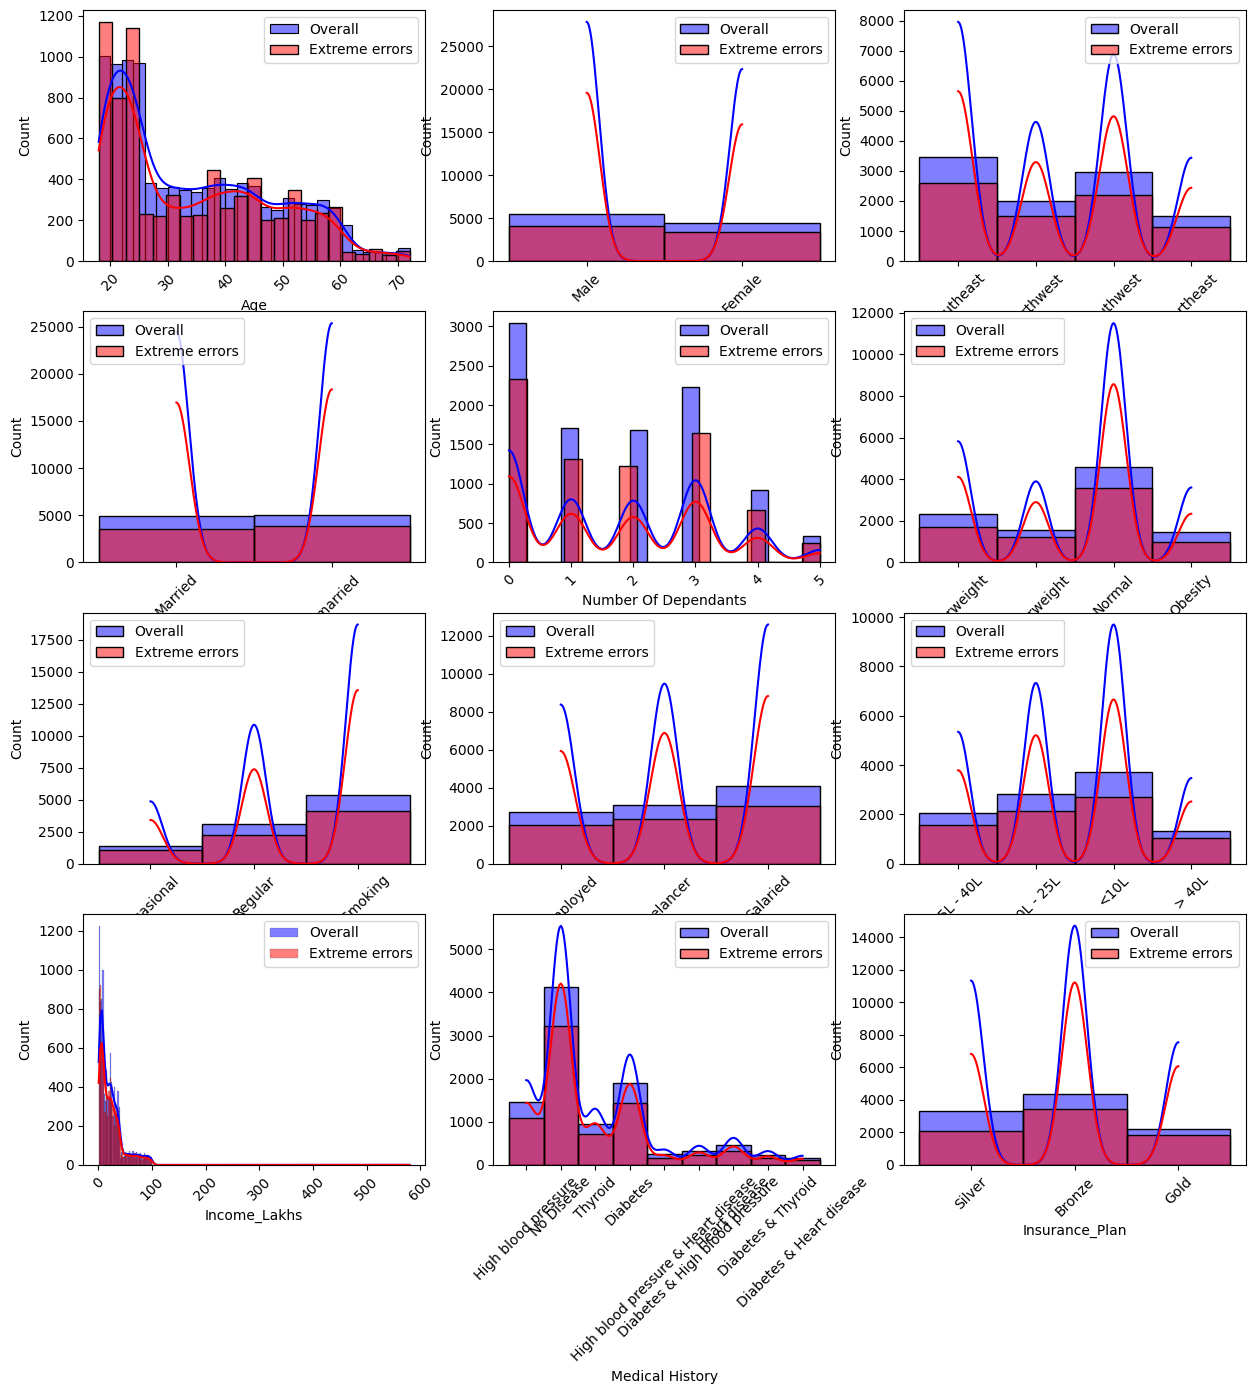

In [67]:
# plot P(X) vs P(X | model makes errors > 10%)
plot_test_distributions_and_extreme_errors_distributions(linreg_extreme_errors_df)

##### RANDOM FOREST REGRESSOR

In [68]:
# find residual pct for each prediction
randforest_residual_pct = ((randforest_test_pred - y_test)/y_test)*100

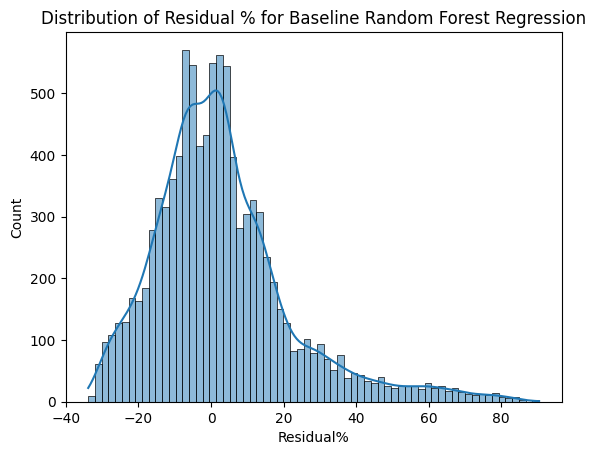

In [69]:
# plot distribution of residual against predictions
sns.histplot(randforest_residual_pct,kde=True)
plt.title("Distribution of Residual % for Baseline Random Forest Regression")
plt.xlabel('Residual%')
plt.show()

In [70]:
# find out samples for which predictions turn out to be extremely erroneous i.e. >10%
indices_of_extreme_errors = randforest_residual_pct[abs(randforest_residual_pct)>10].index
randforest_extreme_errors_df = X_test.loc[indices_of_extreme_errors]

In [71]:
# compute pct of extreme errors
print(f'Baseline Random Forest Regression predictions that have residuals >10% is: {(randforest_extreme_errors_df.shape[0]/X_test_te.shape[0])*100}% of the whole test dataset')

Baseline Random Forest Regression predictions that have residuals >10% is: 50.25216865039338% of the whole test dataset


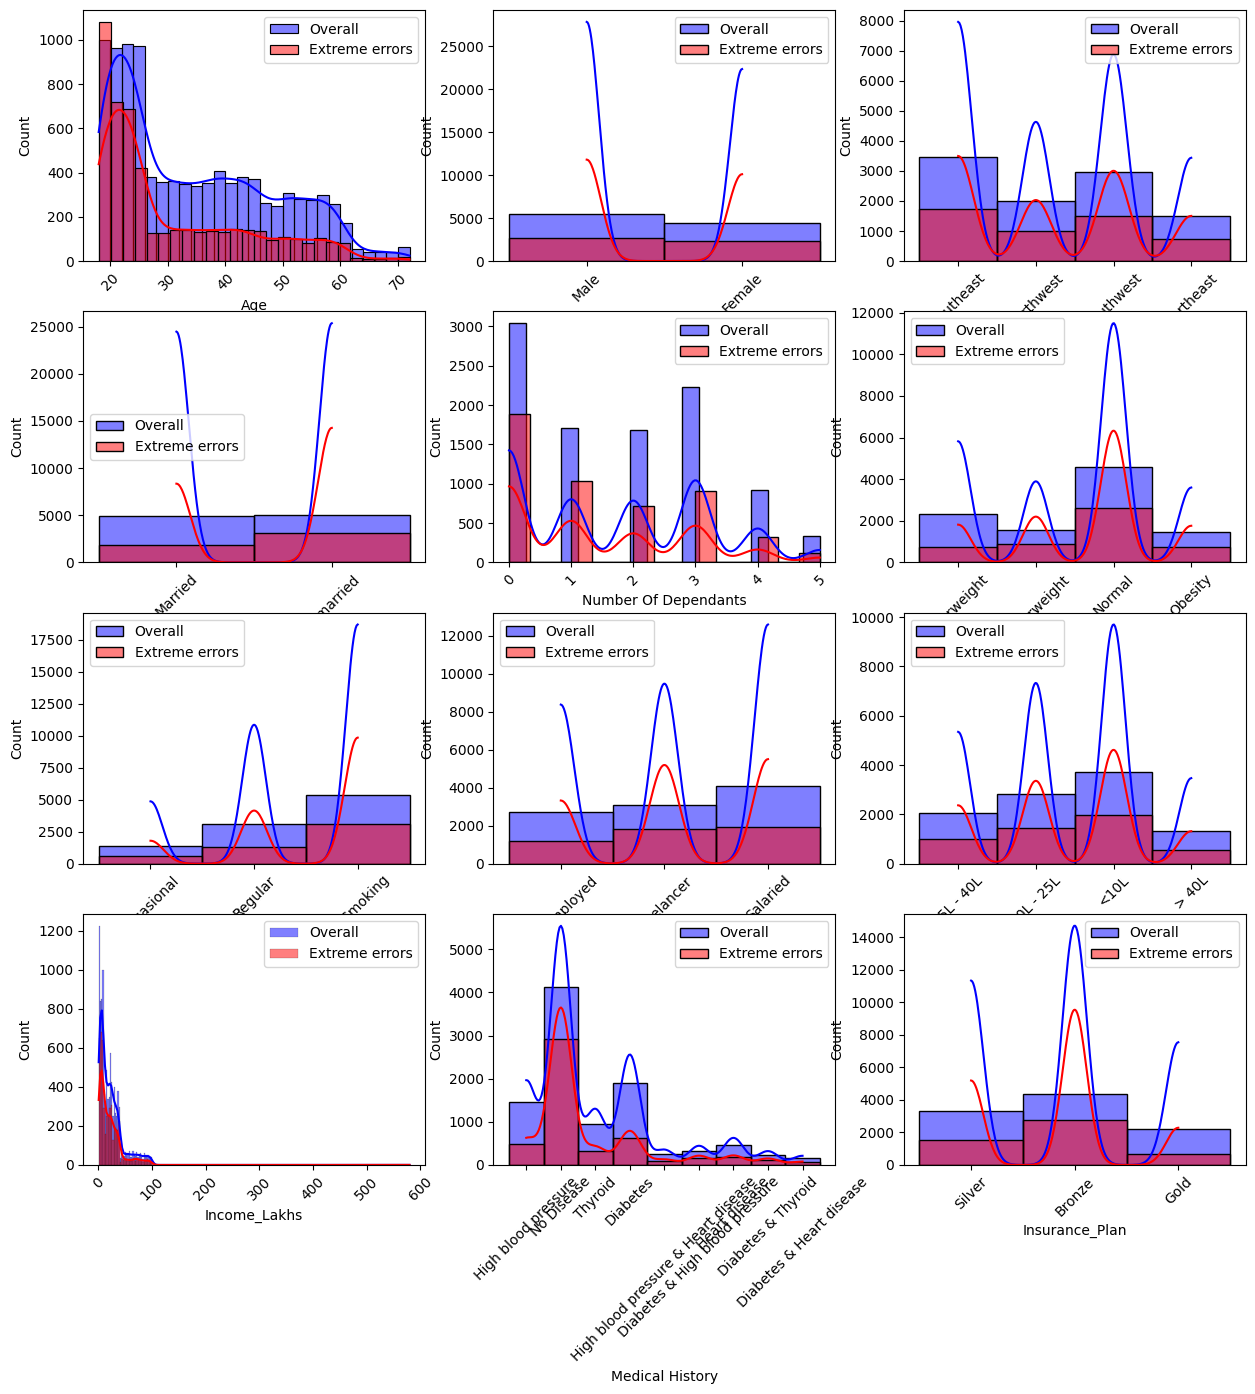

In [72]:
# display P(X) vs P(X | model makes errors > 10%)
plot_test_distributions_and_extreme_errors_distributions(randforest_extreme_errors_df)

##### XGB REGRESSOR

In [73]:
# find residual pct for each prediction
xgbreg_residual_pct = ((xgbreg_test_pred - y_test)/y_test)*100

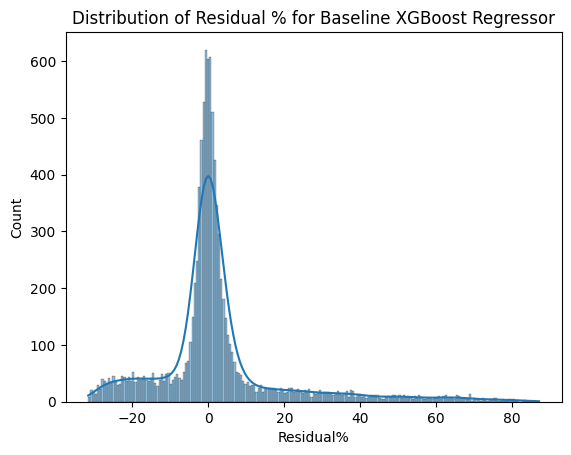

In [74]:
# plot distribution of residual against predictions
sns.histplot(xgbreg_residual_pct,kde=True)
plt.title("Distribution of Residual % for Baseline XGBoost Regressor")
plt.xlabel('Residual%')
plt.show()

In [75]:
# find out samples for which predictions turn out to be extremely erroneous i.e. >10%
indices_of_extreme_errors = xgbreg_residual_pct[abs(xgbreg_residual_pct)>10].index
xgbreg_extreme_errors_df = X_test.loc[indices_of_extreme_errors]

In [76]:
# compute pct of extreme errors
print(f'Baseline XGBoost Regression predictions that have residuals >10% is: {(xgbreg_extreme_errors_df.shape[0]/X_test_te.shape[0])*100}% of the whole test dataset')

Baseline XGBoost Regression predictions that have residuals >10% is: 28.858180351018763% of the whole test dataset


In [77]:
xgbreg_extreme_errors_df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
1,24,Female,Southeast,Unmarried,0,Underweight,Occasional,Freelancer,10L - 25L,16,No Disease,Silver
8,22,Male,Northwest,Unmarried,1,Overweight,Regular,Freelancer,<10L,1,No Disease,Bronze
9,19,Male,Southwest,Unmarried,1,Normal,No Smoking,Salaried,10L - 25L,15,No Disease,Bronze
12,23,Female,Southwest,Unmarried,0,Overweight,No Smoking,Freelancer,10L - 25L,11,No Disease,Silver
16,19,Male,Southeast,Unmarried,0,Overweight,Regular,Freelancer,25L - 40L,33,No Disease,Bronze


In [78]:
X_test.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan
0,28,Male,Southeast,Married,3,Overweight,Occasional,Self-Employed,25L - 40L,30,High blood pressure,Silver
1,24,Female,Southeast,Unmarried,0,Underweight,Occasional,Freelancer,10L - 25L,16,No Disease,Silver
2,31,Male,Southeast,Married,4,Normal,Regular,Salaried,<10L,2,Thyroid,Bronze
3,58,Male,Northwest,Married,3,Overweight,Regular,Self-Employed,<10L,8,Diabetes,Bronze
4,53,Male,Southeast,Married,2,Overweight,Regular,Self-Employed,25L - 40L,30,High blood pressure,Gold


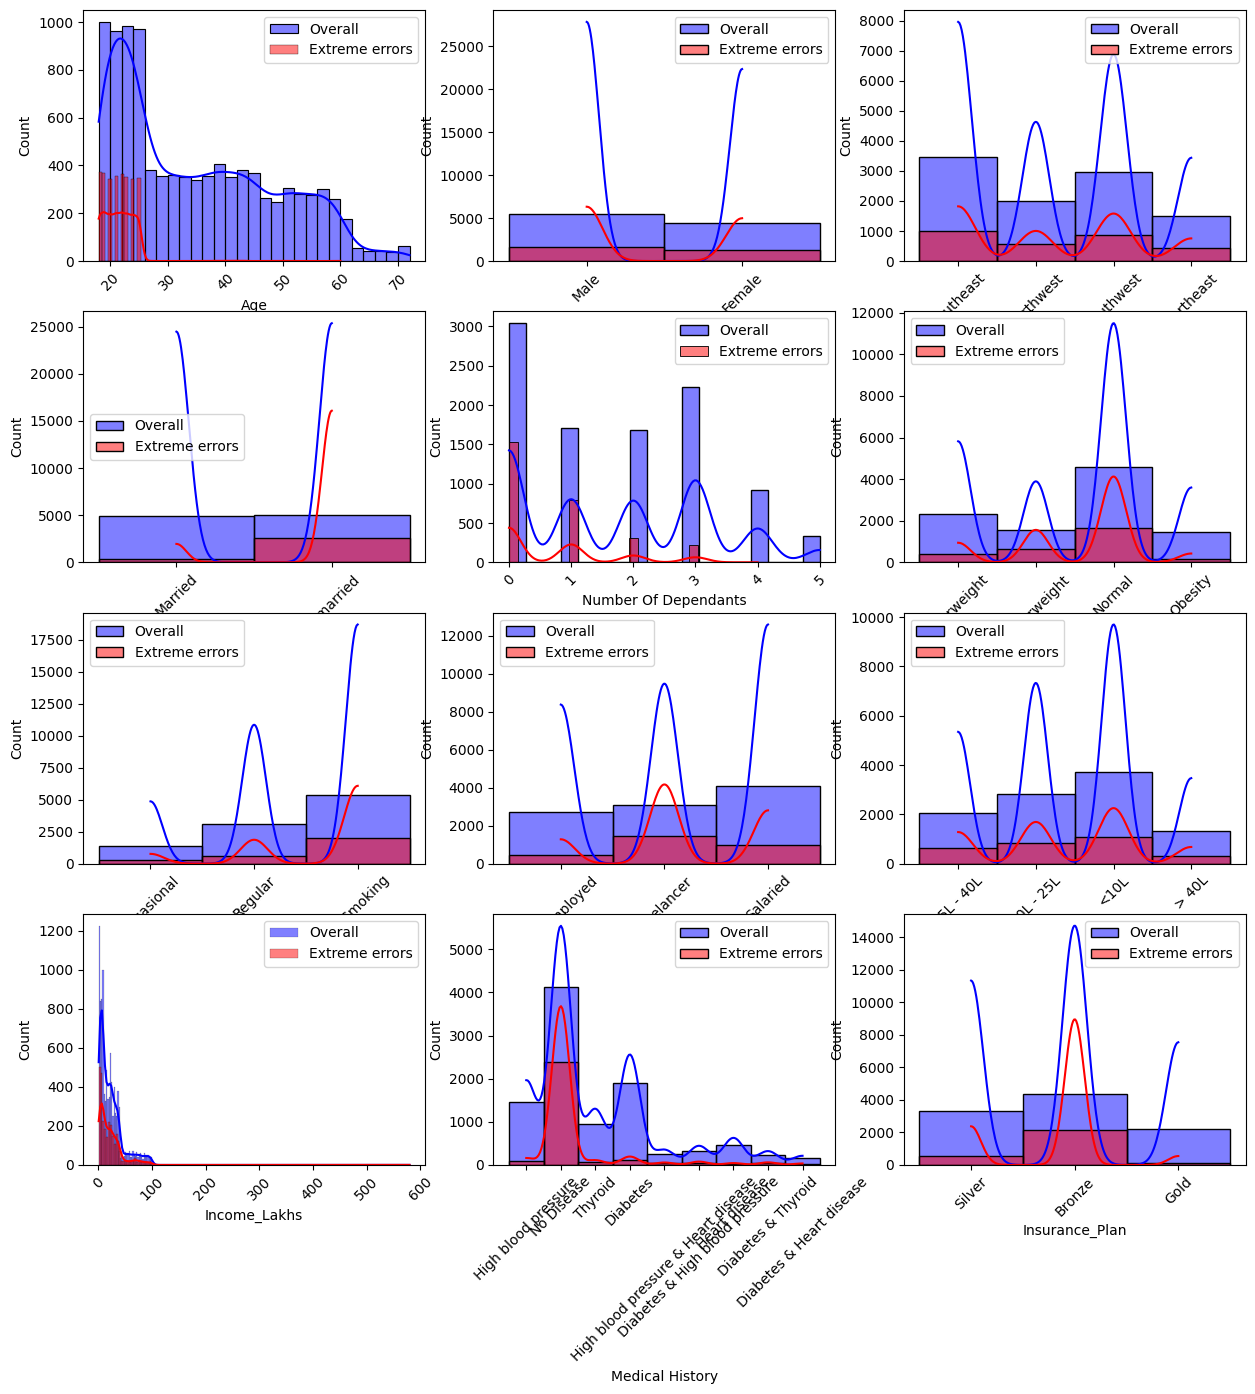

In [79]:
# display P(X) vs P(X | model makes errors > 10%)
plot_test_distributions_and_extreme_errors_distributions(xgbreg_extreme_errors_df)

Observations, 
* From above distributions of residual% we find that *XGBoost Regressor* performs the best with only ~*30%* errors above 10%. 
* Looking at the probability distributions across different models for error samples *XGB Regressor* predicts accurately the target value for people with `Age`>25yrs but fails to do so for `Age`<=25 yrs. 

Hence we may have to have `Model Segmentation` wherein we have seperate models such that one is trained on samples with `Age`>25yrs while another for `Age`<=25yrs.

### MODEL SEGMENTATION
Below we seperate the original dataset into 2 parts - 
* Samples with young customers i.e. Age<=25yrs. 
* Samples with Age>25yrs. 

Next we train different models each on the above 2 datasets and for each pick the most optimal one. 

In addition we add one extra feature - `Genetic Riskfactor` to each of the samples.